ANÁLISIS DE TRÁFICO

1. Montar Drive

In [76]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Comprobar la carpeta capturas_trafico

In [77]:
from pathlib import Path
import pandas as pd

carpeta = Path("/content/drive/MyDrive/capturas_trafico")

if not carpeta.exists():
    raise FileNotFoundError("No se encuentra la carpeta capturas_trafico en Mi unidad")

archivos = sorted([archivo for archivo in carpeta.iterdir() if archivo.is_file()])

print("Archivos encontrados:", len(archivos))
for archivo in archivos:
    print("-", archivo.name)

Archivos encontrados: 30
- amazonshopping_con_dqf.pcap
- amazonshopping_con_dqf_log.csv
- amazonshopping_sin_dqf.pcap
- candycrush_con_dqf.pcap
- candycrush_con_dqf_log.csv
- candycrush_sin_dqf.pcap
- googlemeet_con_dqf.pcap
- googlemeet_con_dqf_log.csv
- googlemeet_sin_dqf.pcap
- operanews_con_dqf.pcap
- operanews_con_dqf_log.csv
- operanews_sin_dqf.pcap
- pinterest_con_dqf.pcap
- pinterest_con_dqf_log.csv
- pinterest_sin_dqf.pcap
- plex_con_dqf.pcap
- plex_con_dqf_log.csv
- plex_sin_dqf.pcap
- simpleradio_con_dqf.pcap
- simpleradio_con_dqf_log.csv
- simpleradio_sin_dqf.pcap
- solitaire_con_dqf.pcap
- solitaire_con_dqf_log.csv
- solitaire_sin_dqf.pcap
- webtoon_con_dqf.pcap
- webtoon_con_dqf_log.csv
- webtoon_sin_dqf.pcap
- wikipedia_con_dqf.pcap
- wikipedia_con_dqf_log.csv
- wikipedia_sin_dqf.pcap


3. Comprobar que cada app tiene sus 3 archivos

In [78]:
apps = {}

for archivo in archivos:
    nombre = archivo.name

    if nombre.endswith("_sin_dqf.pcap"):
        app = nombre.replace("_sin_dqf.pcap", "")
        apps.setdefault(app, {})["sin_dqf"] = archivo.name

    elif nombre.endswith("_con_dqf.pcap"):
        app = nombre.replace("_con_dqf.pcap", "")
        apps.setdefault(app, {})["con_dqf"] = archivo.name

    elif nombre.endswith("_con_dqf_log.csv"):
        app = nombre.replace("_con_dqf_log.csv", "")
        apps.setdefault(app, {})["log_csv"] = archivo.name

resumen_archivos = []

for app, datos in sorted(apps.items()):
    resumen_archivos.append({
        "app": app,
        "pcap_sin_dqf": "OK" if "sin_dqf" in datos else "FALTA",
        "pcap_con_dqf": "OK" if "con_dqf" in datos else "FALTA",
        "csv_con_dqf": "OK" if "log_csv" in datos else "FALTA"
    })

tabla_archivos = pd.DataFrame(resumen_archivos)
tabla_archivos

,app,pcap_sin_dqf,pcap_con_dqf,csv_con_dqf
0,amazonshopping,OK,OK,OK
1,candycrush,OK,OK,OK
2,googlemeet,OK,OK,OK
3,operanews,OK,OK,OK
4,pinterest,OK,OK,OK
5,plex,OK,OK,OK
6,simpleradio,OK,OK,OK
7,solitaire,OK,OK,OK
8,webtoon,OK,OK,OK
9,wikipedia,OK,OK,OK


4. Funciones auxiliares para interpretar archivos PCAP

In [79]:
from pathlib import Path
import struct
import pandas as pd

def leer_cabecera_pcap(datos):
    magic = datos[:4]

    if magic == b"\xd4\xc3\xb2\xa1":
        return "<", 1_000_000
    if magic == b"\xa1\xb2\xc3\xd4":
        return ">", 1_000_000
    if magic == b"\x4d\x3c\xb2\xa1":
        return "<", 1_000_000_000
    if magic == b"\xa1\xb2\x3c\x4d":
        return ">", 1_000_000_000

    raise ValueError("Formato pcap no reconocido")


def inicio_ip(paquete, linktype):
    if linktype == 1:  # Ethernet
        if len(paquete) < 14:
            return None

        tipo = struct.unpack("!H", paquete[12:14])[0]
        if tipo == 0x0800:
            return 14

    elif linktype == 113:  # Linux cooked v1
        if len(paquete) < 16:
            return None

        tipo = struct.unpack("!H", paquete[14:16])[0]
        if tipo == 0x0800:
            return 16

    elif linktype == 276:  # Linux cooked v2
        if len(paquete) < 20:
            return None

        tipo = struct.unpack("!H", paquete[0:2])[0]
        if tipo == 0x0800:
            return 20

    return None


def analizar_paquete(paquete, linktype):
    resultado = {
        "tcp_443": 0,
        "udp_443": 0,
        "tcp_853": 0,
        "udp_53": 0,
        "clienthello_dns_google": 0,
        "conexiones_dot_aprox": 0
    }

    ip_inicio = inicio_ip(paquete, linktype)

    if ip_inicio is None:
        return resultado

    if len(paquete) < ip_inicio + 20:
        return resultado

    version = paquete[ip_inicio] >> 4

    if version != 4:
        return resultado

    ip_header_len = (paquete[ip_inicio] & 0x0F) * 4
    protocolo = paquete[ip_inicio + 9]
    transporte_inicio = ip_inicio + ip_header_len

    if len(paquete) < transporte_inicio + 4:
        return resultado

    puerto_origen = struct.unpack("!H", paquete[transporte_inicio:transporte_inicio + 2])[0]
    puerto_destino = struct.unpack("!H", paquete[transporte_inicio + 2:transporte_inicio + 4])[0]

    if protocolo == 6:  # TCP
        if puerto_origen == 443 or puerto_destino == 443:
            resultado["tcp_443"] = 1

        if puerto_origen == 853 or puerto_destino == 853:
            resultado["tcp_853"] = 1

            if len(paquete) >= transporte_inicio + 14:
                flags = paquete[transporte_inicio + 13]

                syn = (flags & 0x02) != 0
                ack = (flags & 0x10) != 0

                if syn and not ack:
                    resultado["conexiones_dot_aprox"] = 1

        if b"dns.google" in paquete:
            resultado["clienthello_dns_google"] = 1

    elif protocolo == 17:  # UDP
        if puerto_origen == 443 or puerto_destino == 443:
            resultado["udp_443"] = 1

        if puerto_origen == 53 or puerto_destino == 53:
            resultado["udp_53"] = 1

    return resultado

5. Extracción de métricas de una captura PCAP

In [80]:
def analizar_pcap(ruta_pcap):
    datos = ruta_pcap.read_bytes()

    endian, resolucion_tiempo = leer_cabecera_pcap(datos)

    cabecera_global = struct.unpack(endian + "HHIIII", datos[4:24])
    linktype = cabecera_global[5]

    posicion = 24

    paquetes = 0
    bytes_totales = 0

    tcp_443 = 0
    udp_443 = 0
    tcp_853 = 0
    udp_53 = 0
    clienthello_dns_google = 0
    conexiones_dot_aprox = 0

    primer_tiempo = None
    ultimo_tiempo = None
    tiempo_anterior = None
    saltos_mayores_20s = 0
    salto_maximo = 0

    while posicion + 16 <= len(datos):
        ts_seg, ts_frac, incl_len, orig_len = struct.unpack(
            endian + "IIII",
            datos[posicion:posicion + 16]
        )

        posicion += 16

        paquete = datos[posicion:posicion + incl_len]
        posicion += incl_len

        tiempo = ts_seg + (ts_frac / resolucion_tiempo)

        if primer_tiempo is None:
            primer_tiempo = tiempo

        if tiempo_anterior is not None:
            salto = tiempo - tiempo_anterior

            if salto > 20:
                saltos_mayores_20s += 1

            if salto > salto_maximo:
                salto_maximo = salto

        tiempo_anterior = tiempo
        ultimo_tiempo = tiempo

        paquetes += 1
        bytes_totales += incl_len

        datos_paquete = analizar_paquete(paquete, linktype)

        tcp_443 += datos_paquete["tcp_443"]
        udp_443 += datos_paquete["udp_443"]
        tcp_853 += datos_paquete["tcp_853"]
        udp_53 += datos_paquete["udp_53"]
        clienthello_dns_google += datos_paquete["clienthello_dns_google"]
        conexiones_dot_aprox += datos_paquete["conexiones_dot_aprox"]

    duracion_seg = 0

    if primer_tiempo is not None and ultimo_tiempo is not None:
        duracion_seg = ultimo_tiempo - primer_tiempo

    mb = bytes_totales / (1024 * 1024)

    return {
        "archivo": ruta_pcap.name,
        "linktype": linktype,
        "duracion_min": round(duracion_seg / 60, 2),
        "paquetes": paquetes,
        "mb": round(mb, 2),
        "paquetes_por_segundo": round(paquetes / duracion_seg, 2) if duracion_seg > 0 else 0,
        "mb_por_minuto": round(mb / (duracion_seg / 60), 2) if duracion_seg > 0 else 0,
        "tcp_443": tcp_443,
        "udp_443": udp_443,
        "tcp_853_dot": tcp_853,
        "conexiones_dot_aprox": conexiones_dot_aprox,
        "udp_53_dns": udp_53,
        "clienthello_dns_google": clienthello_dns_google,
        "porcentaje_dot": round((tcp_853 / paquetes) * 100, 2) if paquetes > 0 else 0,
        "saltos_mayores_20s": saltos_mayores_20s,
        "salto_maximo_seg": round(salto_maximo, 2)
    }

6. Generación de la tabla resumen de métricas de tráfico

In [81]:
resultados = []

for pcap in sorted(carpeta.glob("*.pcap")):
    nombre = pcap.name

    if nombre.endswith("_sin_dqf.pcap"):
        app = nombre.replace("_sin_dqf.pcap", "")
        escenario = "sin_dqf"

    elif nombre.endswith("_con_dqf.pcap"):
        app = nombre.replace("_con_dqf.pcap", "")
        escenario = "con_dqf"

    else:
        continue

    fila = analizar_pcap(pcap)
    fila["app"] = app
    fila["escenario"] = escenario

    resultados.append(fila)

tabla_pcaps = pd.DataFrame(resultados)

columnas = [
    "app",
    "escenario",
    "archivo",
    "duracion_min",
    "paquetes",
    "mb",
    "paquetes_por_segundo",
    "mb_por_minuto",
    "tcp_443",
    "udp_443",
    "tcp_853_dot",
    "conexiones_dot_aprox",
    "udp_53_dns",
    "clienthello_dns_google",
    "porcentaje_dot",
    "saltos_mayores_20s",
    "salto_maximo_seg",
    "linktype"
]

tabla_pcaps = tabla_pcaps[columnas]

carpeta_resultados = carpeta / "resultados_python"
carpeta_resultados.mkdir(exist_ok=True)

ruta_resumen = carpeta_resultados / "resumen_pcaps.csv"
tabla_pcaps.to_csv(ruta_resumen, index=False)

print("CSV guardado en:")
print(ruta_resumen)

print("\nResumen de capturas:")
display(tabla_pcaps)

print("\nResumen en formato texto:")
print(tabla_pcaps.to_string(index=False))

CSV guardado en:
/content/drive/MyDrive/capturas_trafico/resultados_python/resumen_pcaps.csv

Resumen de capturas:


,app,escenario,archivo,duracion_min,paquetes,mb,paquetes_por_segundo,mb_por_minuto,tcp_443,udp_443,tcp_853_dot,conexiones_dot_aprox,udp_53_dns,clienthello_dns_google,porcentaje_dot,saltos_mayores_20s,salto_maximo_seg,linktype
0,amazonshopping,con_dqf,amazonshopping_con_dqf.pcap,10.96,49302,62.06,74.99,5.66,36161,9036,3414,161,12,159,6.92,0,3.00,276
1,amazonshopping,sin_dqf,amazonshopping_sin_dqf.pcap,10.55,53974,62.10,85.30,5.89,24270,28998,0,0,0,0,0.00,0,3.00,276
2,candycrush,con_dqf,candycrush_con_dqf.pcap,11.17,14902,15.65,22.23,1.40,9462,682,4021,187,12,185,26.98,0,2.65,276
3,candycrush,sin_dqf,candycrush_sin_dqf.pcap,10.84,35594,55.54,54.74,5.12,34471,429,0,0,12,0,0.00,0,3.03,276
4,googlemeet,con_dqf,googlemeet_con_dqf.pcap,10.60,24080,8.96,37.86,0.85,599,2658,2959,134,12,134,12.29,0,2.62,276
5,googlemeet,sin_dqf,googlemeet_sin_dqf.pcap,10.67,17673,5.06,27.60,0.47,348,2060,0,0,4,0,0.00,0,3.00,276
6,operanews,con_dqf,operanews_con_dqf.pcap,10.90,74550,64.46,113.95,5.91,40302,29809,3261,149,22,149,4.37,0,3.95,276
7,operanews,sin_dqf,operanews_sin_dqf.pcap,10.79,72491,72.94,112.00,6.76,23573,47973,0,0,12,0,0.00,0,7.81,276
8,pinterest,con_dqf,pinterest_con_dqf.pcap,10.60,42244,35.56,66.40,3.35,31059,6791,3588,167,0,166,8.49,0,3.00,276
9,pinterest,sin_dqf,pinterest_sin_dqf.pcap,10.50,23575,27.21,37.41,2.59,18981,3451,353,9,8,0,1.50,0,3.00,276



Resumen en formato texto:
           app escenario                     archivo  duracion_min  paquetes     mb  paquetes_por_segundo  mb_por_minuto  tcp_443  udp_443  tcp_853_dot  conexiones_dot_aprox  udp_53_dns  clienthello_dns_google  porcentaje_dot  saltos_mayores_20s  salto_maximo_seg  linktype
amazonshopping   con_dqf amazonshopping_con_dqf.pcap         10.96     49302  62.06                 74.99           5.66    36161     9036         3414                   161          12                     159            6.92                   0              3.00       276
amazonshopping   sin_dqf amazonshopping_sin_dqf.pcap         10.55     53974  62.10                 85.30           5.89    24270    28998            0                     0           0                       0            0.00                   0              3.00       276
    candycrush   con_dqf     candycrush_con_dqf.pcap         11.17     14902  15.65                 22.23           1.40     9462      682         4021

CARACTERIZACIÓN DE TRÁFICO

7. Caracterización de los registros generados por DQF

In [82]:
import pandas as pd

resultados_logs = []

for archivo_csv in sorted(carpeta.glob("*_con_dqf_log.csv")):
    app = archivo_csv.name.replace("_con_dqf_log.csv", "")

    log = pd.read_csv(archivo_csv)

    total = len(log)
    ok = (log["success"] == "OK").sum()
    error = (log["success"] == "ERROR").sum()

    qpm = log["qpm"].dropna().unique()
    jitter = log["jitter_ms"].dropna().unique()

    resultados_logs.append({
        "app": app,
        "consultas_dqf": total,
        "consultas_ok": ok,
        "consultas_error": error,
        "qpm": qpm[0] if len(qpm) > 0 else "-",
        "jitter_ms": jitter[0] if len(jitter) > 0 else "-",
        "dominios_distintos": log["domain"].nunique()
    })

tabla_logs = pd.DataFrame(resultados_logs)

ruta_logs = carpeta_resultados / "resumen_logs_dqf.csv"
tabla_logs.to_csv(ruta_logs, index=False)

print("CSV guardado en:")
print(ruta_logs)

print("\nResumen de logs DQF:")
display(tabla_logs)

print("\nResumen en texto:")
print(tabla_logs.to_string(index=False))

CSV guardado en:
/content/drive/MyDrive/capturas_trafico/resultados_python/resumen_logs_dqf.csv

Resumen de logs DQF:


,app,consultas_dqf,consultas_ok,consultas_error,qpm,jitter_ms,dominios_distintos
0,amazonshopping,160,159,1,30,500,39
1,candycrush,185,185,0,30,500,40
2,googlemeet,134,134,0,30,500,40
3,operanews,146,145,1,30,500,40
4,pinterest,166,166,0,30,500,39
5,plex,122,122,0,30,500,39
6,simpleradio,157,157,0,30,500,40
7,solitaire,144,144,0,30,500,39
8,webtoon,142,137,5,30,500,40
9,wikipedia,178,177,1,30,500,39



Resumen en texto:
           app  consultas_dqf  consultas_ok  consultas_error  qpm  jitter_ms  dominios_distintos
amazonshopping            160           159                1   30        500                  39
    candycrush            185           185                0   30        500                  40
    googlemeet            134           134                0   30        500                  40
     operanews            146           145                1   30        500                  40
     pinterest            166           166                0   30        500                  39
          plex            122           122                0   30        500                  39
   simpleradio            157           157                0   30        500                  40
     solitaire            144           144                0   30        500                  39
       webtoon            142           137                5   30        500                  40
     wikipe

8. Comparativa entre capturas con DQF y sin DQF

In [83]:
sin_dqf = tabla_pcaps[tabla_pcaps["escenario"] == "sin_dqf"].copy()
con_dqf = tabla_pcaps[tabla_pcaps["escenario"] == "con_dqf"].copy()

sin_dqf = sin_dqf.add_suffix("_sin")
con_dqf = con_dqf.add_suffix("_con")

comparativa = pd.merge(
    sin_dqf,
    con_dqf,
    left_on="app_sin",
    right_on="app_con"
)

comparativa["app"] = comparativa["app_sin"]

comparativa = pd.merge(
    comparativa,
    tabla_logs,
    on="app",
    how="left"
)

comparativa["diferencia_tcp_853"] = (
    comparativa["tcp_853_dot_con"] - comparativa["tcp_853_dot_sin"]
)

comparativa["diferencia_conexiones_dot"] = (
    comparativa["conexiones_dot_aprox_con"] - comparativa["conexiones_dot_aprox_sin"]
)

comparativa["diferencia_mb"] = (
    comparativa["mb_con"] - comparativa["mb_sin"]
).round(2)

comparativa["diferencia_paquetes"] = (
    comparativa["paquetes_con"] - comparativa["paquetes_sin"]
)

comparativa["incremento_dot_porcentaje"] = (
    comparativa["porcentaje_dot_con"] - comparativa["porcentaje_dot_sin"]
).round(2)

tabla_comparativa = comparativa[
    [
        "app",
        "duracion_min_sin",
        "duracion_min_con",
        "paquetes_sin",
        "paquetes_con",
        "diferencia_paquetes",
        "mb_sin",
        "mb_con",
        "diferencia_mb",
        "tcp_853_dot_sin",
        "tcp_853_dot_con",
        "diferencia_tcp_853",
        "conexiones_dot_aprox_sin",
        "conexiones_dot_aprox_con",
        "diferencia_conexiones_dot",
        "porcentaje_dot_sin",
        "porcentaje_dot_con",
        "incremento_dot_porcentaje",
        "clienthello_dns_google_sin",
        "clienthello_dns_google_con",
        "consultas_dqf",
        "consultas_ok",
        "consultas_error",
        "qpm",
        "jitter_ms",
        "dominios_distintos"
    ]
]

ruta_comparativa = carpeta_resultados / "comparativa_final_apps.csv"
tabla_comparativa.to_csv(ruta_comparativa, index=False)

print("CSV guardado en:")
print(ruta_comparativa)

print("\nComparativa final por app:")
display(tabla_comparativa)

print("\nComparativa en texto:")
print(tabla_comparativa.to_string(index=False))

CSV guardado en:
/content/drive/MyDrive/capturas_trafico/resultados_python/comparativa_final_apps.csv

Comparativa final por app:


,app,duracion_min_sin,duracion_min_con,paquetes_sin,paquetes_con,diferencia_paquetes,mb_sin,mb_con,diferencia_mb,tcp_853_dot_sin,...,porcentaje_dot_con,incremento_dot_porcentaje,clienthello_dns_google_sin,clienthello_dns_google_con,consultas_dqf,consultas_ok,consultas_error,qpm,jitter_ms,dominios_distintos
0,amazonshopping,10.55,10.96,53974,49302,-4672,62.10,62.06,-0.04,0,...,6.92,6.92,0,159,160,159,1,30,500,39
1,candycrush,10.84,11.17,35594,14902,-20692,55.54,15.65,-39.89,0,...,26.98,26.98,0,185,185,185,0,30,500,40
2,googlemeet,10.67,10.60,17673,24080,6407,5.06,8.96,3.90,0,...,12.29,12.29,0,134,134,134,0,30,500,40
3,operanews,10.79,10.90,72491,74550,2059,72.94,64.46,-8.48,0,...,4.37,4.37,0,149,146,145,1,30,500,40
4,pinterest,10.50,10.60,23575,42244,18669,27.21,35.56,8.35,353,...,8.49,6.99,0,166,166,166,0,30,500,39
5,plex,11.57,11.00,118928,86760,-32168,212.94,181.78,-31.16,78,...,2.95,2.88,4,121,122,122,0,30,500,39
6,simpleradio,10.90,10.90,19952,27657,7705,16.34,22.30,5.96,0,...,12.81,12.81,16,163,157,157,0,30,500,40
7,solitaire,10.75,10.57,25601,23658,-1943,21.42,19.74,-1.68,0,...,13.32,13.32,12,144,144,144,0,30,500,39
8,webtoon,11.04,11.19,41589,31872,-9717,53.07,37.45,-15.62,39,...,9.80,9.71,2,146,142,137,5,30,500,40
9,wikipedia,10.98,10.77,21669,30138,8469,26.03,40.27,14.24,319,...,12.54,11.07,14,178,178,177,1,30,500,39



Comparativa en texto:
           app  duracion_min_sin  duracion_min_con  paquetes_sin  paquetes_con  diferencia_paquetes  mb_sin  mb_con  diferencia_mb  tcp_853_dot_sin  tcp_853_dot_con  diferencia_tcp_853  conexiones_dot_aprox_sin  conexiones_dot_aprox_con  diferencia_conexiones_dot  porcentaje_dot_sin  porcentaje_dot_con  incremento_dot_porcentaje  clienthello_dns_google_sin  clienthello_dns_google_con  consultas_dqf  consultas_ok  consultas_error  qpm  jitter_ms  dominios_distintos
amazonshopping             10.55             10.96         53974         49302                -4672   62.10   62.06          -0.04                0             3414                3414                         0                       161                        161                0.00                6.92                       6.92                           0                         159            160           159                1   30        500                  39
    candycrush             10.84       

9. Gráfica de tráfico DoT con y sin DQF

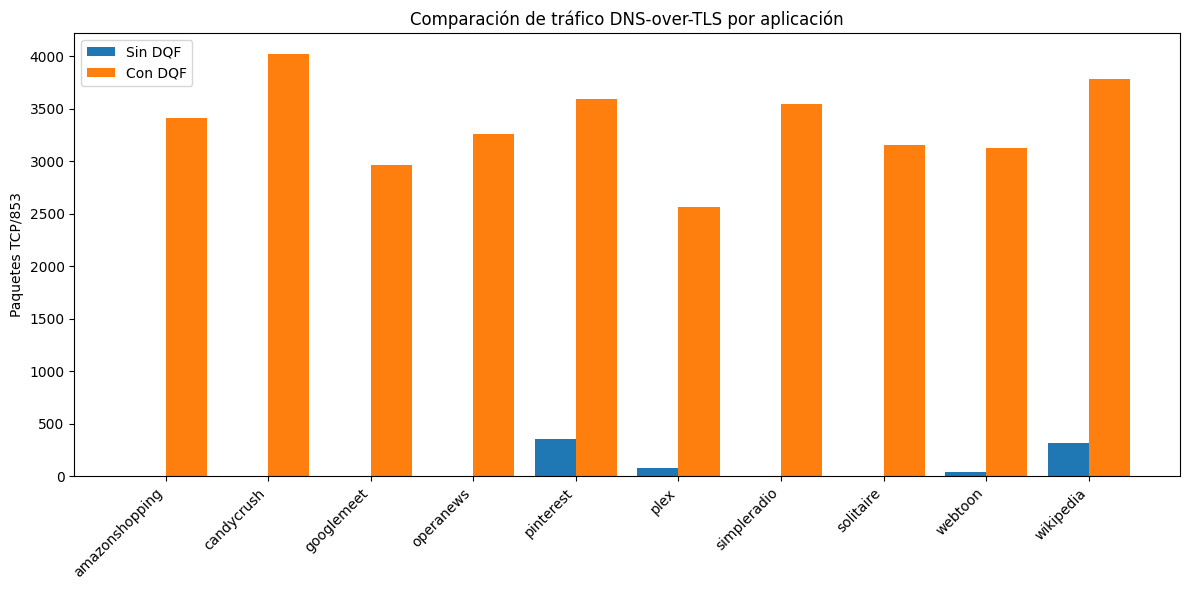

Gráfica guardada en:
/content/drive/MyDrive/capturas_trafico/resultados_python/grafica_tcp853_dot.png


In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

x = range(len(tabla_comparativa["app"]))

plt.bar(
    [i - 0.2 for i in x],
    tabla_comparativa["tcp_853_dot_sin"],
    width=0.4,
    label="Sin DQF"
)

plt.bar(
    [i + 0.2 for i in x],
    tabla_comparativa["tcp_853_dot_con"],
    width=0.4,
    label="Con DQF"
)

plt.xticks(x, tabla_comparativa["app"], rotation=45, ha="right")
plt.ylabel("Paquetes TCP/853")
plt.title("Comparación de tráfico DNS-over-TLS por aplicación")
plt.legend()
plt.tight_layout()

ruta_grafica_dot = carpeta_resultados / "grafica_tcp853_dot.png"
plt.savefig(ruta_grafica_dot, dpi=300)
plt.show()

print("Gráfica guardada en:")
print(ruta_grafica_dot)

10. Gráfica de volumen total de tráfico

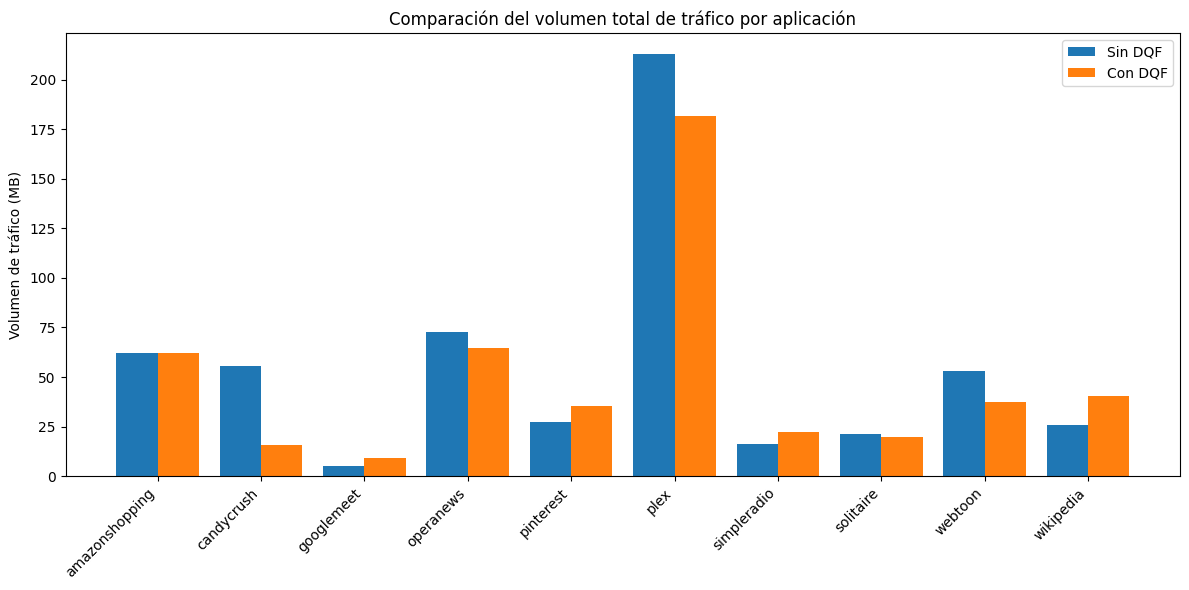

Gráfica guardada en:
/content/drive/MyDrive/capturas_trafico/resultados_python/grafica_volumen_mb.png


In [85]:
plt.figure(figsize=(12, 6))

x = range(len(tabla_comparativa["app"]))

plt.bar(
    [i - 0.2 for i in x],
    tabla_comparativa["mb_sin"],
    width=0.4,
    label="Sin DQF"
)

plt.bar(
    [i + 0.2 for i in x],
    tabla_comparativa["mb_con"],
    width=0.4,
    label="Con DQF"
)

plt.xticks(x, tabla_comparativa["app"], rotation=45, ha="right")
plt.ylabel("Volumen de tráfico (MB)")
plt.title("Comparación del volumen total de tráfico por aplicación")
plt.legend()
plt.tight_layout()

ruta_grafica_mb = carpeta_resultados / "grafica_volumen_mb.png"
plt.savefig(ruta_grafica_mb, dpi=300)
plt.show()

print("Gráfica guardada en:")
print(ruta_grafica_mb)

11. Gráfica de consultas generadas por DQF

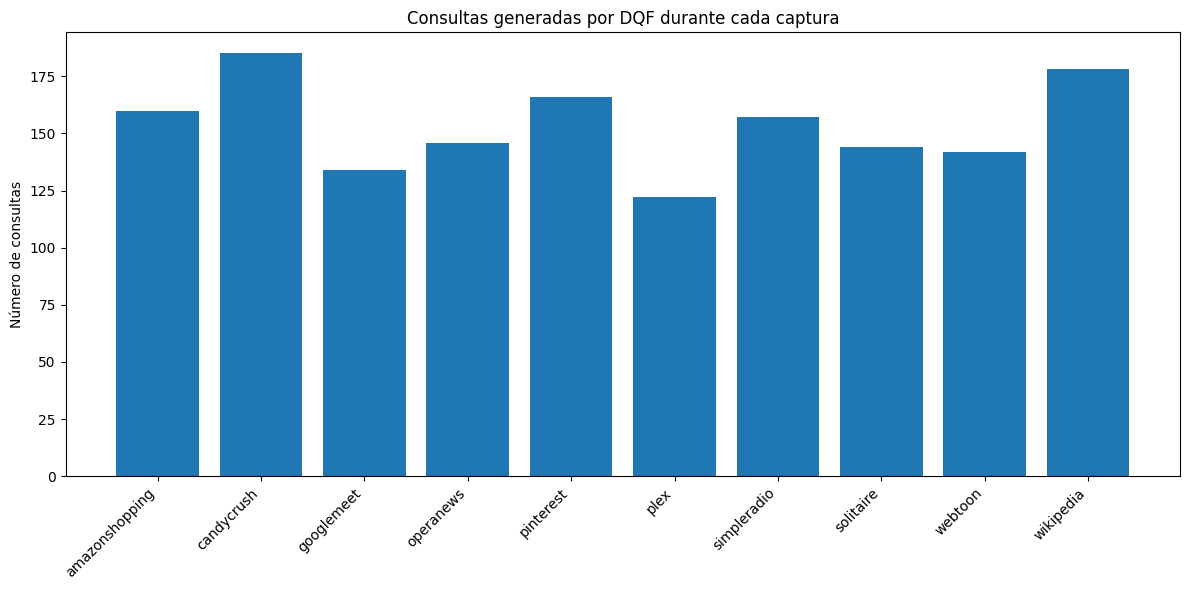

Gráfica guardada en:
/content/drive/MyDrive/capturas_trafico/resultados_python/grafica_consultas_dqf.png


In [86]:
plt.figure(figsize=(12, 6))

plt.bar(
    tabla_logs["app"],
    tabla_logs["consultas_dqf"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Número de consultas")
plt.title("Consultas generadas por DQF durante cada captura")
plt.tight_layout()

ruta_grafica_consultas = carpeta_resultados / "grafica_consultas_dqf.png"
plt.savefig(ruta_grafica_consultas, dpi=300)
plt.show()

print("Gráfica guardada en:")
print(ruta_grafica_consultas)

12. Gráfica de errores de DQF

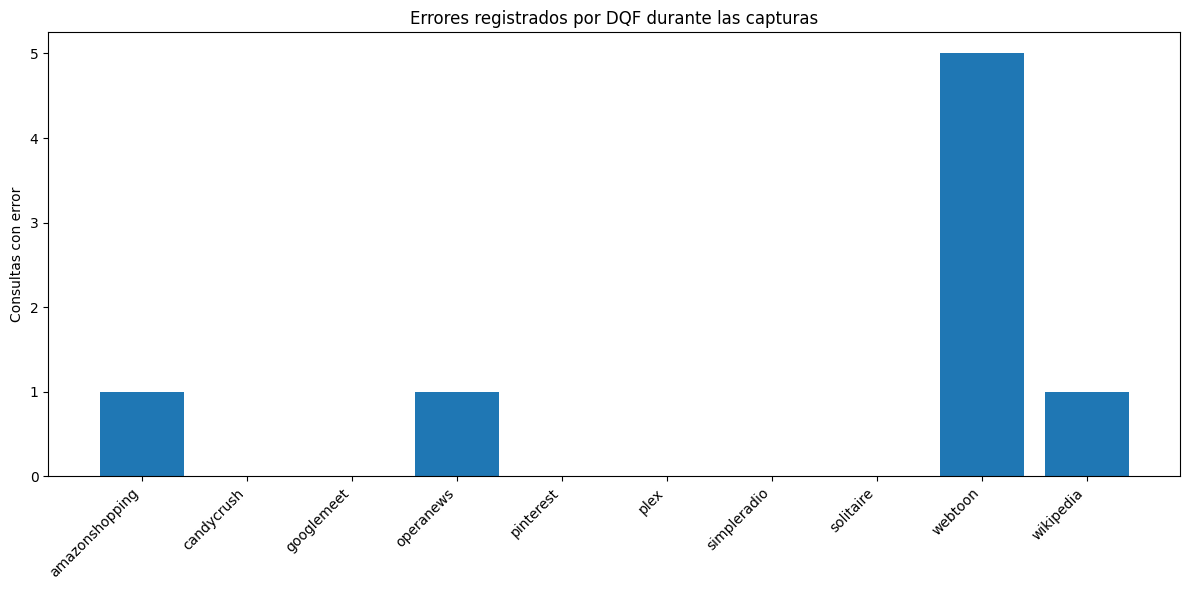

Gráfica guardada en:
/content/drive/MyDrive/capturas_trafico/resultados_python/grafica_errores_dqf.png


In [87]:
plt.figure(figsize=(12, 6))

plt.bar(
    tabla_logs["app"],
    tabla_logs["consultas_error"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Consultas con error")
plt.title("Errores registrados por DQF durante las capturas")
plt.tight_layout()

ruta_grafica_errores = carpeta_resultados / "grafica_errores_dqf.png"
plt.savefig(ruta_grafica_errores, dpi=300)
plt.show()

print("Gráfica guardada en:")
print(ruta_grafica_errores)

13. Gráfica del porcentaje de tráfico DoT

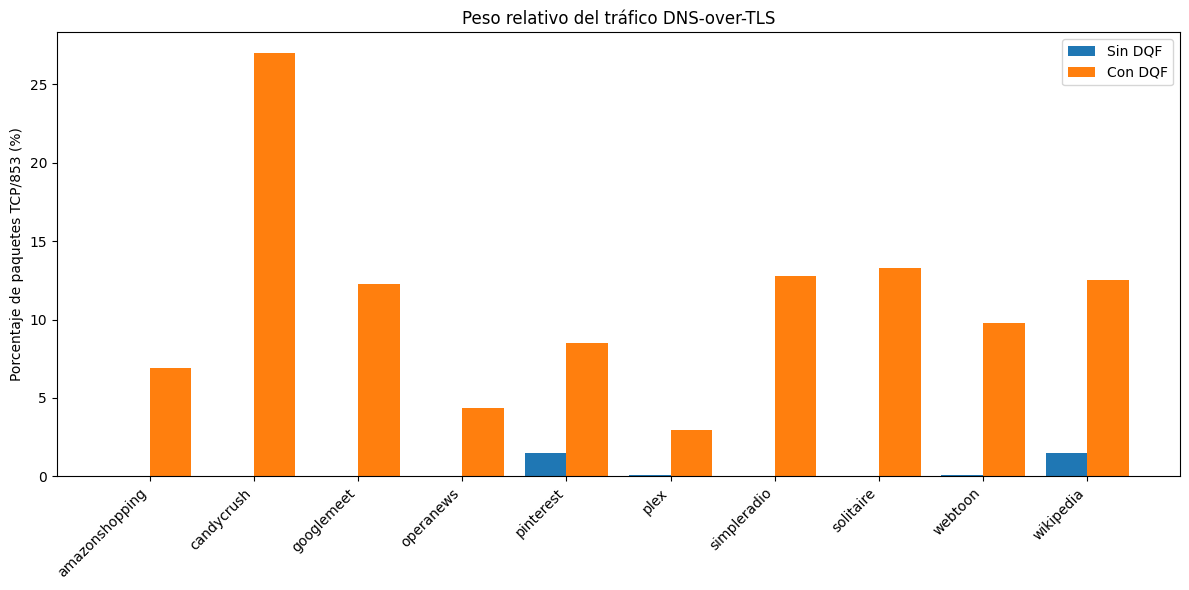

Gráfica guardada en:
/content/drive/MyDrive/capturas_trafico/resultados_python/grafica_porcentaje_dot.png


In [88]:
plt.figure(figsize=(12, 6))

x = range(len(tabla_comparativa["app"]))

plt.bar(
    [i - 0.2 for i in x],
    tabla_comparativa["porcentaje_dot_sin"],
    width=0.4,
    label="Sin DQF"
)

plt.bar(
    [i + 0.2 for i in x],
    tabla_comparativa["porcentaje_dot_con"],
    width=0.4,
    label="Con DQF"
)

plt.xticks(x, tabla_comparativa["app"], rotation=45, ha="right")
plt.ylabel("Porcentaje de paquetes TCP/853 (%)")
plt.title("Peso relativo del tráfico DNS-over-TLS")
plt.legend()
plt.tight_layout()

ruta_grafica_porcentaje_dot = carpeta_resultados / "grafica_porcentaje_dot.png"
plt.savefig(ruta_grafica_porcentaje_dot, dpi=300)
plt.show()

print("Gráfica guardada en:")
print(ruta_grafica_porcentaje_dot)

14. Composición porcentual del tráfico por captura

CSV guardado en:
/content/drive/MyDrive/capturas_trafico/resultados_python/composicion_trafico_porcentual.csv


,captura,TCP/443 HTTPS,UDP/443 QUIC,TCP/853 DoT,UDP/53 DNS,Otros
1,amazonshopping - sin_dqf,44.97,53.73,0.00,0.00,1.31
0,amazonshopping - con_dqf,73.35,18.33,6.92,0.02,1.38
3,candycrush - sin_dqf,96.84,1.21,0.00,0.03,1.92
2,candycrush - con_dqf,63.49,4.58,26.98,0.08,4.87
5,googlemeet - sin_dqf,1.97,11.66,0.00,0.02,86.35
4,googlemeet - con_dqf,2.49,11.04,12.29,0.05,74.14
7,operanews - sin_dqf,32.52,66.18,0.00,0.02,1.29
6,operanews - con_dqf,54.06,39.99,4.37,0.03,1.55
9,pinterest - sin_dqf,80.51,14.64,1.50,0.03,3.32
8,pinterest - con_dqf,73.52,16.08,8.49,0.00,1.91


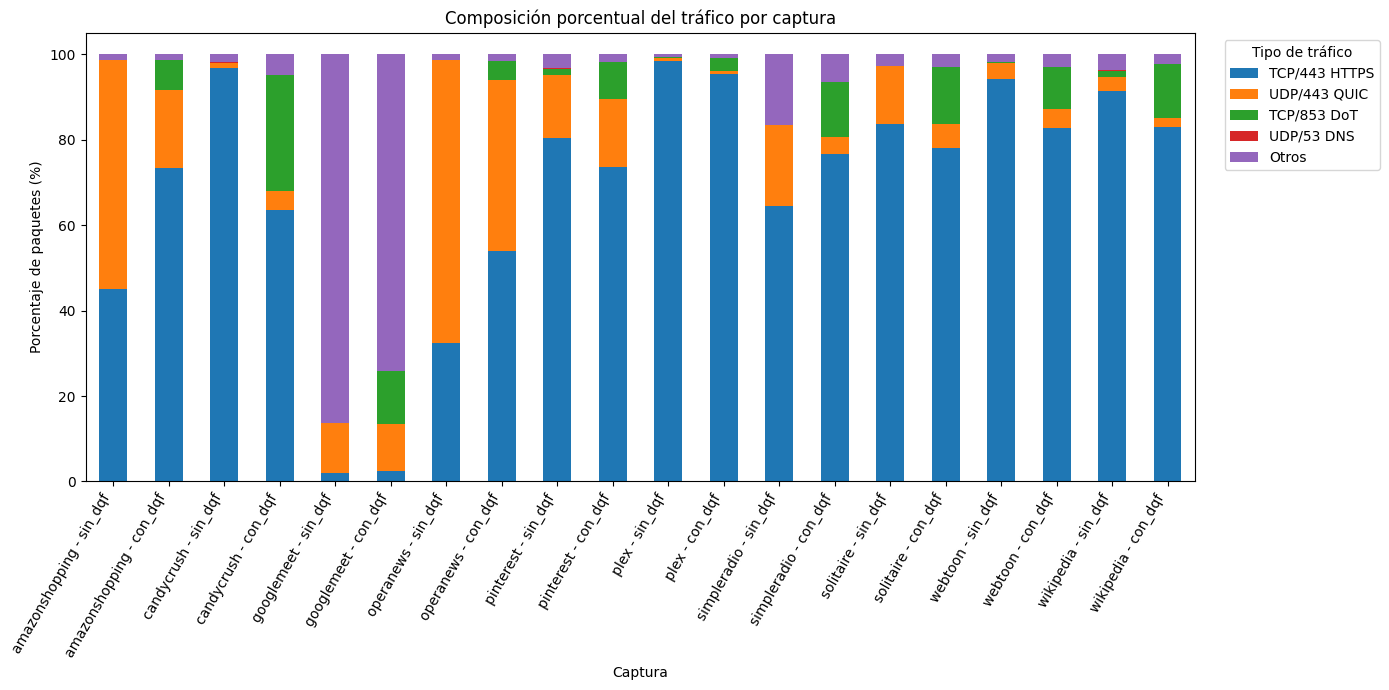

Gráfica guardada en:
/content/drive/MyDrive/capturas_trafico/resultados_python/grafica_composicion_trafico.png


In [89]:
tipos_trafico = [
    "tcp_443",
    "udp_443",
    "tcp_853_dot",
    "udp_53_dns"
]

composicion = tabla_pcaps[
    [
        "app",
        "escenario",
        "paquetes",
        "tcp_443",
        "udp_443",
        "tcp_853_dot",
        "udp_53_dns"
    ]
].copy()

composicion["otros"] = (
    composicion["paquetes"]
    - composicion["tcp_443"]
    - composicion["udp_443"]
    - composicion["tcp_853_dot"]
    - composicion["udp_53_dns"]
)

composicion["otros"] = composicion["otros"].clip(lower=0)

columnas_porcentaje = [
    "tcp_443",
    "udp_443",
    "tcp_853_dot",
    "udp_53_dns",
    "otros"
]

for columna in columnas_porcentaje:
    composicion[columna] = (
        composicion[columna] / composicion["paquetes"] * 100
    ).round(2)

composicion["orden"] = composicion["escenario"].map({
    "sin_dqf": 0,
    "con_dqf": 1
})

composicion = composicion.sort_values(["app", "orden"])

composicion["captura"] = (
    composicion["app"] + " - " + composicion["escenario"]
)

tabla_composicion = composicion[
    [
        "captura",
        "tcp_443",
        "udp_443",
        "tcp_853_dot",
        "udp_53_dns",
        "otros"
    ]
].copy()

tabla_composicion = tabla_composicion.rename(columns={
    "tcp_443": "TCP/443 HTTPS",
    "udp_443": "UDP/443 QUIC",
    "tcp_853_dot": "TCP/853 DoT",
    "udp_53_dns": "UDP/53 DNS",
    "otros": "Otros"
})

ruta_composicion = carpeta_resultados / "composicion_trafico_porcentual.csv"
tabla_composicion.to_csv(ruta_composicion, index=False)

print("CSV guardado en:")
print(ruta_composicion)

display(tabla_composicion)

grafica_composicion = tabla_composicion.set_index("captura")

grafica_composicion.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.ylabel("Porcentaje de paquetes (%)")
plt.xlabel("Captura")
plt.title("Composición porcentual del tráfico por captura")
plt.xticks(rotation=60, ha="right")
plt.legend(title="Tipo de tráfico", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

ruta_grafica_composicion = carpeta_resultados / "grafica_composicion_trafico.png"
plt.savefig(ruta_grafica_composicion, dpi=300)
plt.show()

print("Gráfica guardada en:")
print(ruta_grafica_composicion)

15. Tabla resumen final para la memoria

In [90]:
tabla_memoria = tabla_comparativa[
    [
        "app",
        "mb_sin",
        "mb_con",
        "diferencia_mb",
        "tcp_853_dot_sin",
        "tcp_853_dot_con",
        "diferencia_tcp_853",
        "conexiones_dot_aprox_sin",
        "conexiones_dot_aprox_con",
        "diferencia_conexiones_dot",
        "porcentaje_dot_sin",
        "porcentaje_dot_con",
        "consultas_dqf",
        "consultas_ok",
        "consultas_error",
        "dominios_distintos"
    ]
].copy()

tabla_memoria = tabla_memoria.rename(columns={
    "app": "Aplicación",
    "mb_sin": "MB sin DQF",
    "mb_con": "MB con DQF",
    "diferencia_mb": "Diferencia MB",
    "tcp_853_dot_sin": "TCP/853 sin DQF",
    "tcp_853_dot_con": "TCP/853 con DQF",
    "diferencia_tcp_853": "Incremento TCP/853",
    "conexiones_dot_aprox_sin": "Conexiones DoT sin DQF",
    "conexiones_dot_aprox_con": "Conexiones DoT con DQF",
    "diferencia_conexiones_dot": "Incremento conexiones DoT",
    "porcentaje_dot_sin": "% DoT sin DQF",
    "porcentaje_dot_con": "% DoT con DQF",
    "consultas_dqf": "Consultas DQF",
    "consultas_ok": "Consultas OK",
    "consultas_error": "Consultas error",
    "dominios_distintos": "Dominios distintos"
})

ruta_tabla_memoria = carpeta_resultados / "tabla_resumen_memoria.csv"
tabla_memoria.to_csv(ruta_tabla_memoria, index=False)

print("CSV guardado en:")
print(ruta_tabla_memoria)

display(tabla_memoria)

CSV guardado en:
/content/drive/MyDrive/capturas_trafico/resultados_python/tabla_resumen_memoria.csv


,Aplicación,MB sin DQF,MB con DQF,Diferencia MB,TCP/853 sin DQF,TCP/853 con DQF,Incremento TCP/853,Conexiones DoT sin DQF,Conexiones DoT con DQF,Incremento conexiones DoT,% DoT sin DQF,% DoT con DQF,Consultas DQF,Consultas OK,Consultas error,Dominios distintos
0,amazonshopping,62.10,62.06,-0.04,0,3414,3414,0,161,161,0.00,6.92,160,159,1,39
1,candycrush,55.54,15.65,-39.89,0,4021,4021,0,187,187,0.00,26.98,185,185,0,40
2,googlemeet,5.06,8.96,3.90,0,2959,2959,0,134,134,0.00,12.29,134,134,0,40
3,operanews,72.94,64.46,-8.48,0,3261,3261,0,149,149,0.00,4.37,146,145,1,40
4,pinterest,27.21,35.56,8.35,353,3588,3235,9,167,158,1.50,8.49,166,166,0,39
5,plex,212.94,181.78,-31.16,78,2561,2483,4,119,115,0.07,2.95,122,122,0,39
6,simpleradio,16.34,22.30,5.96,0,3543,3543,0,158,158,0.00,12.81,157,157,0,40
7,solitaire,21.42,19.74,-1.68,0,3151,3151,0,144,144,0.00,13.32,144,144,0,39
8,webtoon,53.07,37.45,-15.62,39,3122,3083,2,146,144,0.09,9.80,142,137,5,40
9,wikipedia,26.03,40.27,14.24,319,3778,3459,14,178,164,1.47,12.54,178,177,1,39
